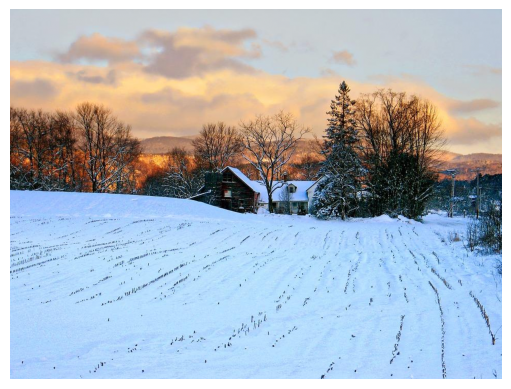

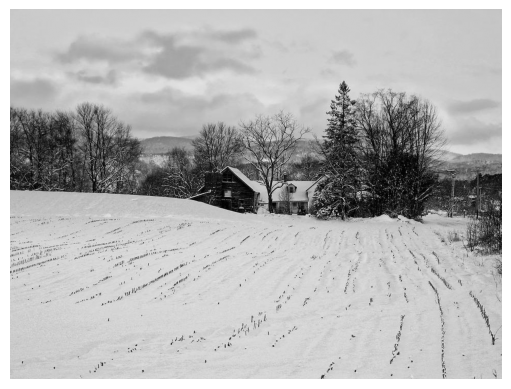

In [55]:
# 1(a) Read Winter.png, display in color, display in grayscale
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def read_image(rgbImage: Image.Image):
    rgb = np.asarray(Image.open(rgbImage).convert("RGB"), dtype=np.float64) / 255.0
    return rgb

def rgb_to_gray(rgb):
    return 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]

def display_rgb_image(rgb):
    plt.imshow(rgb); plt.axis("off"); plt.show()

def display_gray_image(gray):
    plt.imshow(gray, cmap="gray", vmin=0, vmax=1); plt.axis("off"); plt.show()

winterRgb = read_image("Winter.png")
winterGray = rgb_to_gray(winterRgb)
display_rgb_image(winterRgb)
display_gray_image(winterGray)

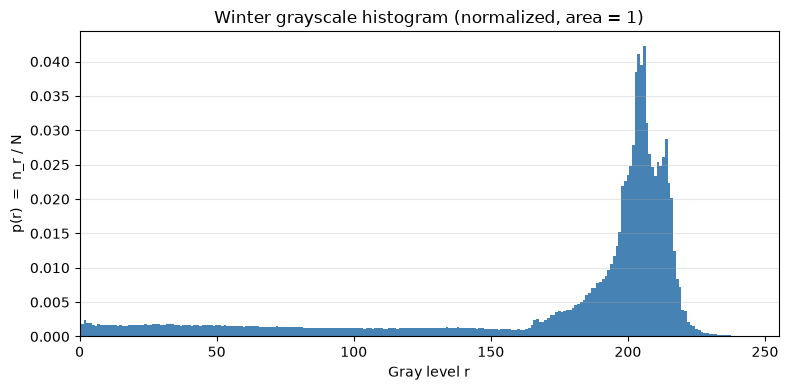

In [ ]:
# 1(b) Plot the black and white histogram and normalize so that the area under the
# histogram is equal to one.
from numpy import uint8
def to_uint8(gray01):
    return np.clip(np.round(gray01 * 255), 0, 255).astype(uint8)
    
def histogram_pmf(gray01, n_bins=256):
    u8 = to_uint8(gray01)
    counts = np.bincount(u8.ravel(), minlength=n_bins).astype(np.float64)
    pmf = counts / counts.sum()          # area under the histogram = 1
    return np.arange(n_bins), pmf, counts

def build_histogram(gray01, n_bins=256):
    u8 = to_uint8(gray01)
    counts = np.bincount(u8.ravel(), minlength=n_bins).astype(np.float64)
    return np.arange(n_bins), counts

def show_histogram(gray01, title="Histogram", color="steelblue"):
    bins, pmf, counts = histogram_pmf(gray01)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(bins, pmf, width=1.0, color=color, edgecolor="none")
    ax.set_xlim(0, 255)
    ax.set_xlabel("Gray level r")
    ax.set_ylabel("p(r)  =  n_r / N")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


show_histogram(winterGray, title="Winter grayscale histogram (normalized, area = 1)", color="steelblue")

1(c) Crop any region of 100-by-100 pixels where there is snow on the ground, display, and plot its histogram

I cropped a patch on the open snow field (row 480, col 220). It is still snow, but it also contains the dark stubble rows, so the patch is not a single gray value.

In [44]:
print(winterGray.shape)

(719, 957)


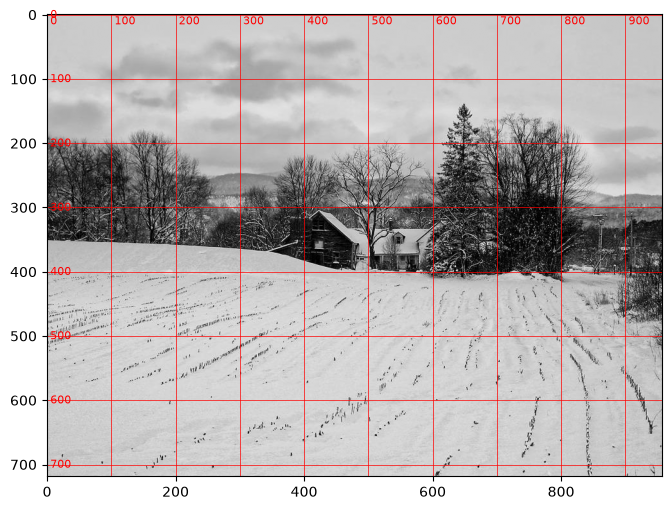

In [57]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(winterGray, cmap="gray", vmin=0, vmax=1)
H, W = winterGray.shape
for r in range(0, H, 100):
    ax.axhline(r, color="red", lw=0.5)
    ax.text(5, r+5, str(r), color="red", fontsize=8)
for c in range(0, W, 100):
    ax.axvline(c, color="red", lw=0.5)
    ax.text(c+5, 15, str(c), color="red", fontsize=8)
plt.show()

In [58]:
r0, c0 = 400, 200          # top-left corner of the crop (adjust as you like)
h, w   = 100, 100

snow_patch = winterGray[r0:r0+h, c0:c0+w]   # float, [0, 1]

print("patch:", snow_patch.shape, snow_patch.dtype,
      "range:", snow_patch.min(), snow_patch.max())

patch: (100, 100) float64 range: 0.032141176470588236 0.9659960784313725


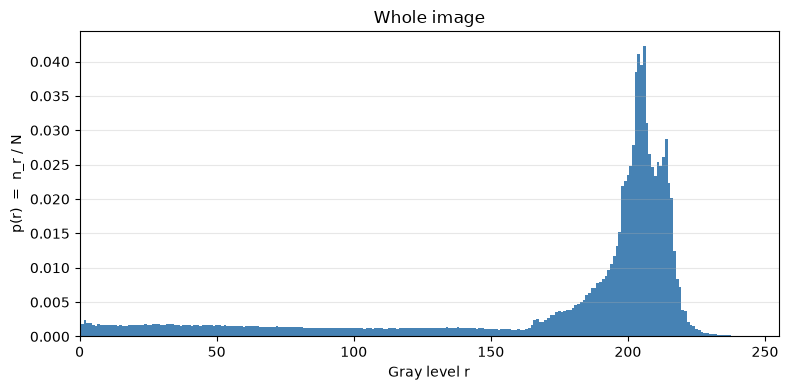

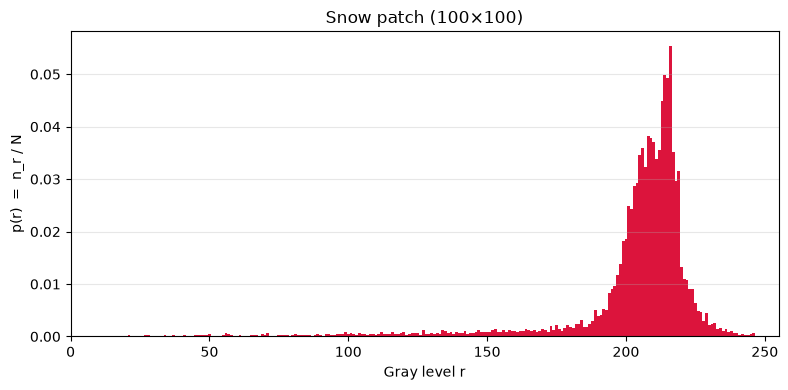

full: 0.0 0.9953960784313726
patch: 0.032141176470588236 0.9659960784313725


In [71]:
# show image and histogram of the patch
show_histogram(winterGray, title="Whole image")
show_histogram(snow_patch, title=f"Snow patch ({h}×{w})", color="crimson")

print("full:", winterGray.min(), winterGray.max())
print("patch:", snow_patch.min(), snow_patch.max())

Compare the histograms of the entire image and the subregion by overlaying on
top of each other!

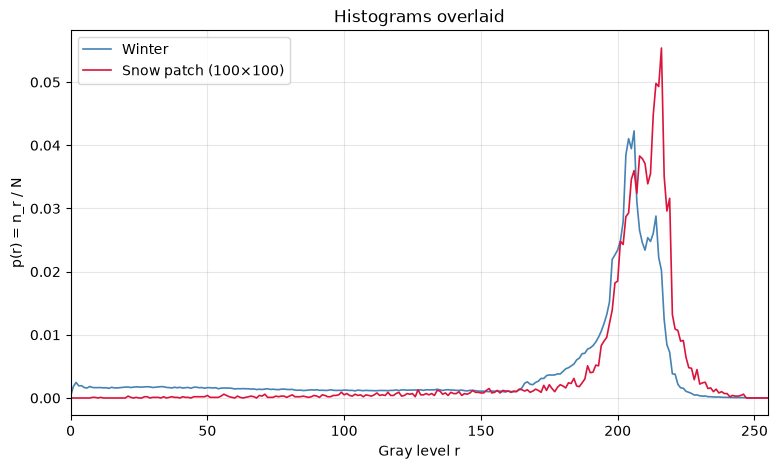

In [77]:
def overlay_histograms(gray1, gray2, label1="Image 1", label2="Image 2"):
    bins, pmf1, _ = histogram_pmf(gray1)
    _, pmf2, _ = histogram_pmf(gray2)
    
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(bins, pmf1, color="steelblue", lw=1.2, label=label1)
    ax.plot(bins, pmf2, color="crimson",   lw=1.2, label=label2)
    ax.set_xlim(0, 255)
    ax.set_xlabel("Gray level r")
    ax.set_ylabel("p(r) = n_r / N")
    ax.set_title("Histograms overlaid")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

overlay_histograms(winterGray, snow_patch, label1="Winter", label2=f"Snow patch ({h}×{w})")

1e. Read Desert.png, convert to a black and white image, and display.

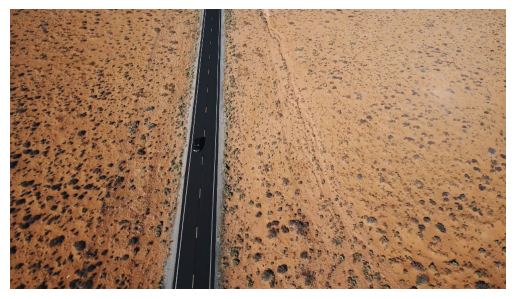

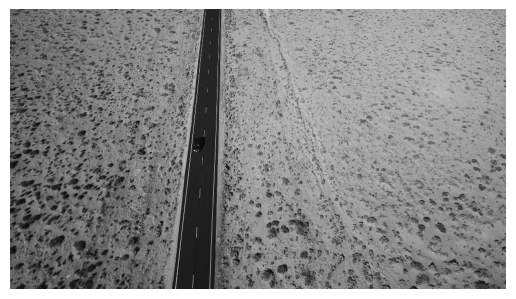

In [60]:
desertRgb = read_image("Desert.png")
desertGray = rgb_to_gray(desertRgb)
display_rgb_image(desertRgb)
display_gray_image(desertGray)

Compare the histograms of (e) and (b) by overlaying them. Can these two
images be discriminated by their histogram?

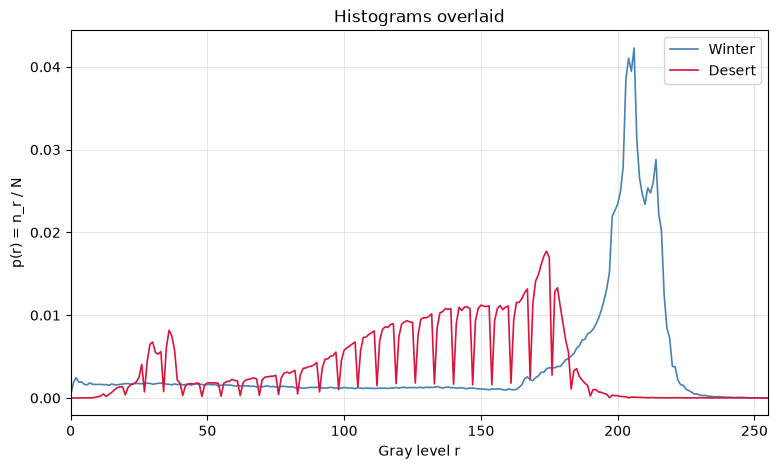

In [79]:
overlay_histograms(winterGray, desertGray, label1="Winter", label2="Desert")